In [10]:
# ============================================================
# IMPORTING REQUIRED LIBRARIES
# This section imports all necessary libraries for:
# - Image processing
# - Machine Learning
# - Visualization
# - Model evaluation
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import zipfile

In [11]:
# ============================================================
# EXTRACTING ZIP FILE
# This section extracts the dataset ZIP file
# ============================================================


zip_path = "/content/archive (21).zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [12]:
# ============================================================
# LOADING DATASET IMAGES
# This section:
# - Reads images from dataset folders
# - Assigns labels
# - Resizes images
# - Stores image data and labels
# ============================================================

base_path = "/content/dataset"

categories = ["yes", "no"]

data = []
labels = []

IMG_SIZE = 128

for category in categories:

    folder_path = os.path.join(base_path, category)

    label = categories.index(category)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is not None:

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append(img)

            labels.append(label)

print("Total Images Loaded:", len(data))

Total Images Loaded: 253


In [13]:
# ============================================================
# CONVERTING DATA INTO NUMPY ARRAYS
# This section converts:
# - Image list into numpy array
# - Labels into numpy array
# ============================================================

X = np.array(data)
y = np.array(labels)

print("Shape of Images:", X.shape)
print("Shape of Labels:", y.shape)

Shape of Images: (253, 128, 128, 3)
Shape of Labels: (253,)


In [14]:
# ============================================================
# NORMALIZING IMAGE PIXEL VALUES
# This section scales pixel values from:
# 0-255  --->  0-1
# This helps improve model performance
# ============================================================

X = X / 255.0

In [15]:
# ============================================================
# FLATTENING IMAGES
# Machine Learning models require 2D input
# This converts image matrices into single vectors
# ============================================================

X = X.reshape(X.shape[0], -1)

print("Flattened Shape:", X.shape)

Flattened Shape: (253, 49152)


In [16]:
# ============================================================
# SPLITTING DATASET
# This section divides dataset into:
# - Training data
# - Testing data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 202
Testing Samples: 51


In [17]:
# ============================================================
# TRAINING LOGISTIC REGRESSION MODEL
# This section:
# - Creates Logistic Regression model
# - Trains model using training data
# ============================================================

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [18]:
# ============================================================
# PREDICTING USING LOGISTIC REGRESSION
# This section:
# - Predicts test data labels
# - Stores predictions
# ============================================================

y_pred_log = log_model.predict(X_test)

In [19]:
# ============================================================
# EVALUATING LOGISTIC REGRESSION MODEL
# This section displays:
# - Accuracy
# - Classification Report
# - Confusion Matrix
# ============================================================

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7254901960784313

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.81      0.76        27
           1       0.75      0.62      0.68        24

    accuracy                           0.73        51
   macro avg       0.73      0.72      0.72        51
weighted avg       0.73      0.73      0.72        51


Confusion Matrix:

[[22  5]
 [ 9 15]]


In [20]:
# ============================================================
# TRAINING SUPPORT VECTOR MACHINE (SVM)
# This section creates and trains SVM model
# ============================================================

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [21]:
# ============================================================
# PREDICTING USING SVM MODEL
# This section predicts labels using SVM
# ============================================================

y_pred_svm = svm_model.predict(X_test)

In [22]:
# ============================================================
# EVALUATING SVM MODEL
# This section evaluates SVM performance
# ============================================================

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.7254901960784313

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.81      0.76        27
           1       0.75      0.62      0.68        24

    accuracy                           0.73        51
   macro avg       0.73      0.72      0.72        51
weighted avg       0.73      0.73      0.72        51


Confusion Matrix:

[[22  5]
 [ 9 15]]


In [23]:
# ============================================================
# HYPERPARAMETER TUNING USING GRIDSEARCHCV
# This section finds best SVM parameters
# ============================================================

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.6s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.5s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.6s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.5s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.5s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.7s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.5s
[CV] END ...................C=0.1, gamma=auto, k

In [24]:
# ============================================================
# TESTING BEST SVM MODEL
# This section predicts using tuned SVM model
# ============================================================

best_model = grid.best_estimator_

best_predictions = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, best_predictions)

print("Best SVM Accuracy:", best_accuracy)

Best SVM Accuracy: 0.7647058823529411


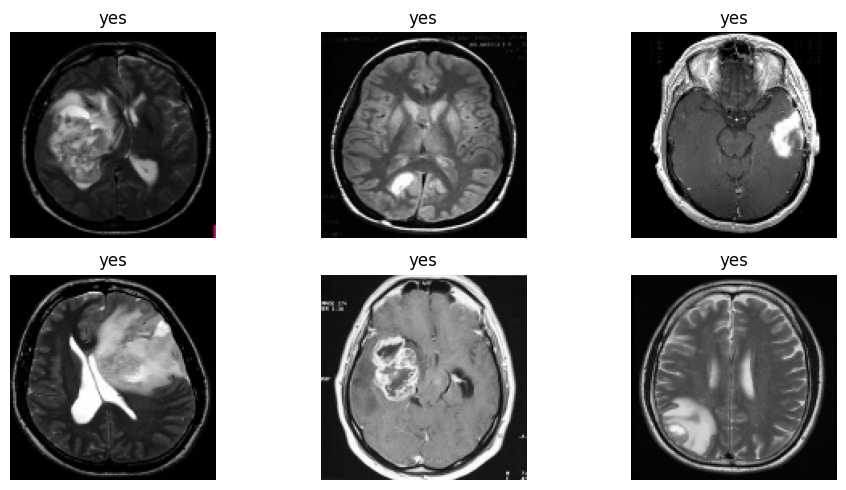

In [25]:
# ============================================================
# DISPLAYING SAMPLE IMAGES
# This section shows sample images with labels
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    img = data[i]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(categories[labels[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# PREDICTING A NEW IMAGE
# This section:
# - Loads a new image
# - Preprocesses it
# - Predicts its category
# ============================================================

test_image_path = "/content/Y2.jpg"

img = cv2.imread(test_image_path)

img = cv2.resize(img, (128, 128))

img = img / 255.0

img = img.reshape(1, -1)

prediction = best_model.predict(img)

print("Brain Tumor? :", categories[prediction[0]])

Brain Tumor? : yes
